# Section 14 — Exploratory analysis and the first threshold estimate (steps 72–79)

**The final section of the Phoenix pilot — and the first scientific result.** It looks at the
central relationship of the whole project, the tree **cooling advantage** against **compound
stress** (the CSI), and produces a **first threshold estimate** for Phoenix. A threshold, if
present, appears as a clear **bend**: cooling advantage roughly flat / slowly declining at low
stress, then dropping more steeply beyond some point — and, mechanistically, **ET should fall
beyond the same stress level**.

> **Re-run on branch `temporal-ndmi-supply` (time-varying CSI supply axis).** This is a re-run of
> the original Section 14 after the **CSI supply axis was unfrozen**: the NDMI water-supply z-score
> is now a **temporal day-of-year leave-one-year-out anomaly** (§4b/§11/§12), so `mean_csi_tree`
> and `mean_water_supply_z_tree` now **vary per overpass *and* across neighborhoods**, instead of
> the old static-in-time spatial field. `cooling_advantage` (from LST) is unchanged. The decisive
> question here is whether the richer supply axis **moves the original "no robust threshold"
> result**. An explicit **old-vs-new comparison** is reported in the final cell. (The original
> static-NDMI result is preserved on `main`, commit `711c7f9`.)

This notebook reads **only** `data/processed/master_table.parquet` (the Section 13 deliverable)
and imports the reusable analysis logic from `src/section14_threshold.py` (unit-tested in
`src/test_section14_threshold.py`), so every number and figure here is reproducible from saved
code.

## The honesty gate (the protocol's *common pitfall*, non-negotiable)
> A segmented (piecewise) regression **always** returns a breakpoint — even for a straight
> line or pure noise. Do **not** report a threshold on the strength of one fit.

We therefore report a Phoenix threshold as **credible only if ALL THREE hold**:
1. the **two methods agree** within their uncertainty — the segmented-regression breakpoint
   (with a bootstrap CI) and the **independent** `ruptures` change-point;
2. a **bend is visible** in the binned plot (post-breakpoint slope clearly steeper);
3. **ET declines** beyond the same CSI level (the mechanistic signature).

Otherwise the honest result is **“no robust threshold detected”** — a valid finding, not a
failure. We also compare the segmented fit against a plain **linear** fit (ΔR² / ΔAIC): if the
kink buys little over a straight line, that is itself evidence against a threshold.

## Data-adequacy caveats we carry throughout (from Sections 10–13)
- **Thin paired sample (UNCHANGED by the supply-axis fix).** Only **9 paired block groups**, and
  **one** (`040139412001`, ~171 tree px) dominates; the other 8 rest on **1–6 tree px** (median
  `n_good_obs` = 2). A strict minimum-count filter collapses the sample toward that single
  well-sampled BG — so we report **both** (a) the full 9-BG sample (noisy) and (b) the robust
  single-BG subset (≈ temporal-only) and reconcile them. **This limitation is the same as in the
  original run** and still stands even now that the supply-axis limitation is fixed.
- **What drives the CSI axis (CHANGED — the point of this re-run).** The water-supply (NDMI) z is
  now a **temporal day-of-year LOYO anomaly** (§11 redo), so it **varies in both space and time**,
  and the CSI's row-to-row variation now comes from **both** the VPD (demand) **and** NDMI (supply)
  sides. The between-neighborhood spread of BG-mean CSI grows accordingly (quantified in step 75:
  **0.027 → ≈ 0.081**, ~3× the static-field value); it is no longer ~10× smaller than the within-BG
  temporal spread. So the CSI is **no longer ≈ a pure VPD-demand axis** — the supply axis now
  contributes real spatial contrast.
- **ET coverage.** `mean_et_tree` / `mean_esi_tree` are NaN on ~22.7 % of rows (the non-ET
  overpasses) — dropped pairwise in the ET overlay, never imputed.

## 0. Setup — imports, config, and the analysis module

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Repo root on sys.path so `config` and the Section 14 module import.
_REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (_REPO, _REPO / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import config
import section14_threshold as s14

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})
FIGS = config.FIGURES_DIR
FIGS.mkdir(parents=True, exist_ok=True)
print("repo:", _REPO)
print("master table:", (config.PROCESSED_DIR / "master_table.parquet"))
print("section14 module:", s14.__file__)

repo: C:\Users\pingp\Documents\TreeProject\project
master table: C:\Users\pingp\Documents\TreeProject\project\data\processed\master_table.parquet
section14 module: C:\Users\pingp\Documents\TreeProject\project\src\section14_threshold.py


## 1. Load the master table (the ONLY input)

One row per (paired neighborhood, overpass). We add two derived helper columns used only for QC
(step 75): **local Phoenix hour** (UTC−7; Arizona has no DST) and **month**. We do not modify
any analysis column.

In [2]:
mt = pd.read_parquet(config.PROCESSED_DIR / "master_table.parquet")

ts = pd.to_datetime(mt["overpass_timestamp"])
mt["local_hour"] = (ts.dt.hour - 7) % 24          # MST = UTC-7, no DST in Arizona
mt["month"] = ts.dt.month
mt["is_day"] = (mt["local_hour"] >= 7) & (mt["local_hour"] < 19)

print(f"rows={len(mt)}  neighborhoods={mt['neighborhood_id'].nunique()}  "
      f"overpasses={mt['overpass_key'].nunique()}")
print("columns:", list(mt.columns)[:26])
mt[[s14.OUTCOME_COL, s14.CSI_COL, s14.ET_COL, s14.ESI_COL, s14.COUNT_COL]].describe().round(3)

rows=264  neighborhoods=9  overpasses=54
columns: ['neighborhood_id', 'overpass_timestamp', 'overpass_key', 'city', 'cooling_advantage', 'mean_lst_tree', 'mean_lst_reference', 'mean_et_tree', 'mean_esi_tree', 'mean_csi_tree', 'mean_vpd_z_tree', 'mean_water_supply_z_tree', 'mean_impervious', 'mean_canopy', 'aridity', 'irrigation_proxy', 'functional_type', 'functional_leaf_habit', 'median_income', 'pct_poc', 'svi', 'n_tree_px', 'n_ref_px', 'n_tree_valid', 'n_ref_valid', 'n_good_obs']


,cooling_advantage,mean_csi_tree,mean_et_tree,mean_esi_tree,n_tree_valid
count,264.000,264.000,204.000,204.000,264.000
mean,3.660,0.350,194.690,0.580,16.803
std,3.941,0.321,110.023,0.127,43.596
min,-6.350,0.000,0.000,0.000,1.000
25%,0.700,0.066,104.322,0.561,1.000
50%,2.811,0.250,209.667,0.605,2.000
75%,6.268,0.555,277.925,0.640,5.000
max,23.056,1.498,436.607,0.727,171.000


## Step 72 — Scatter: cooling advantage vs CSI, one point per neighborhood per overpass

We colour by neighborhood and size by `n_tree_valid` (so the single well-sampled BG and the
many single-pixel rows are visually distinct). We also print the headline shape descriptors
(Pearson / Spearman correlation, OLS slope) — **before** fitting any threshold.

SHAPE of the cooling-advantage vs CSI cloud (full sample, n=264):
  Pearson  r = +0.023  (p = 0.714)
  Spearman r = +0.014  (p = 0.817)
  OLS slope  = +0.279 K per CSI unit


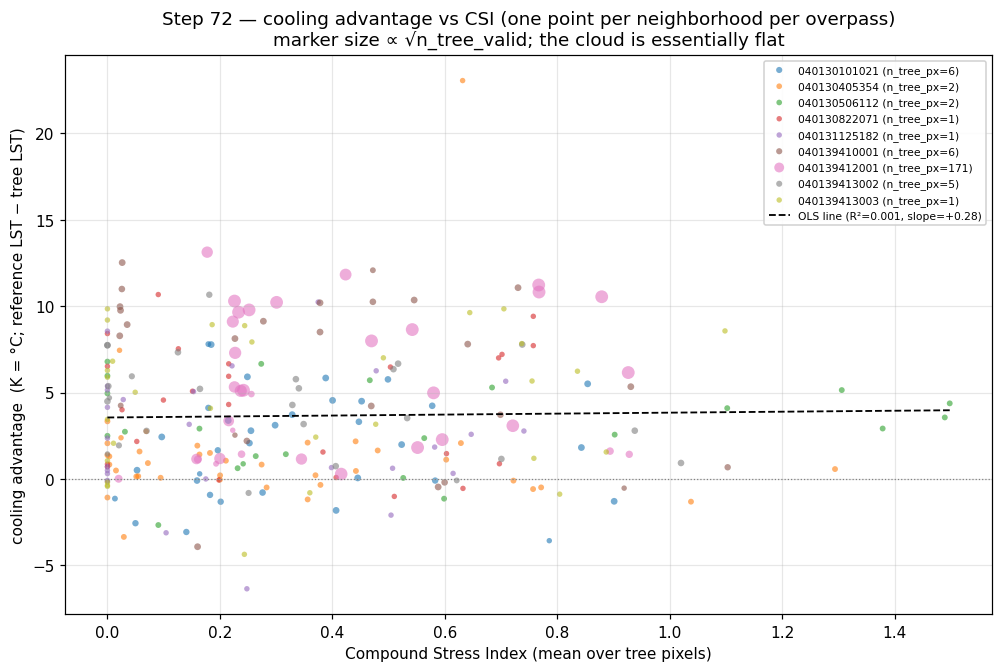

In [3]:
x_all = mt[s14.CSI_COL].to_numpy()
y_all = mt[s14.OUTCOME_COL].to_numpy()

shape = s14.describe_shape(x_all, y_all)
print("SHAPE of the cooling-advantage vs CSI cloud (full sample, n=%d):" % shape["n"])
print(f"  Pearson  r = {shape['pearson_r']:+.3f}  (p = {shape['pearson_p']:.3f})")
print(f"  Spearman r = {shape['spearman_r']:+.3f}  (p = {shape['spearman_p']:.3f})")
print(f"  OLS slope  = {shape['ols_slope']:+.3f} K per CSI unit")

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
neighs = sorted(mt["neighborhood_id"].unique())
cmap = plt.get_cmap("tab10")
for i, g in enumerate(neighs):
    sub = mt[mt["neighborhood_id"] == g]
    ax.scatter(sub[s14.CSI_COL], sub[s14.OUTCOME_COL],
               s=8 + 1.2 * np.sqrt(sub[s14.COUNT_COL]) * 4,
               color=cmap(i % 10), alpha=0.6, edgecolor="none",
               label=f"{g} (n_tree_px={int(sub['n_tree_px'].iloc[0])})")
# OLS line for reference (R^2 is ~0).
xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 50)
lin = s14.linear_fit(x_all, y_all)
ax.plot(xs, lin["intercept"] + lin["slope"] * xs, "k--", lw=1.2,
        label=f"OLS line (R²={lin['r2']:.3f}, slope={lin['slope']:+.2f})")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Compound Stress Index (mean over tree pixels)")
ax.set_ylabel("cooling advantage  (K = °C; reference LST − tree LST)")
ax.set_title("Step 72 — cooling advantage vs CSI (one point per neighborhood per overpass)\n"
             "marker size ∝ √n_tree_valid; the cloud is essentially flat")
ax.legend(fontsize=7, loc="upper right", ncol=1, framealpha=0.9)
fig.savefig(FIGS / "section14_scatter_ca_vs_csi.png", bbox_inches="tight")
plt.show()

**Shape read-out.** The cloud is **still essentially flat** even with the richer (time-varying)
supply axis: the Pearson and Spearman correlations are within ±0.1 of zero (Pearson r ≈ **+0.02**,
p ≈ 0.71; the sign even flips slightly *positive* vs the original run's −0.05) and the OLS line
explains **~0 %** of the variance. There is no visible monotonic decline of cooling advantage with
compound stress. Most of the spread is **vertical scatter** (a wide cooling-advantage range at
every CSI level), much of it from single-tree-pixel neighborhoods. This near-zero relationship is
the first — and decisive — piece of evidence, and **unfreezing the supply axis did not change it**.

## Step 73 — Bin the CSI; per-bin mean cooling advantage ± error bars (look for a bend)

A threshold would show here as a clear **bend** — flat at low CSI, then dropping beyond some bin.
We overlay the per-bin sample size so sparsely-populated high-CSI bins are obvious.

 bin_center   n  mean_ca   sem
      0.094 100    3.543 0.381
      0.281  58    3.324 0.482
      0.468  40    4.262 0.634
      0.655  33    4.078 0.841
      0.843  22    3.706 0.934
      1.030   6    2.629 1.411
      1.217   2    2.863 2.285
      1.404   3    3.622 0.421


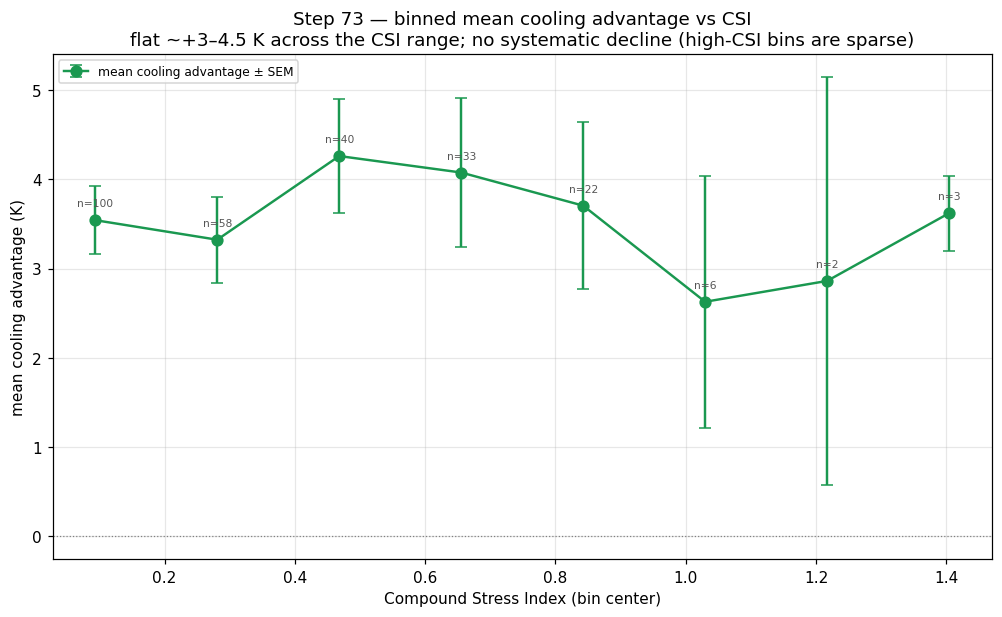

In [4]:
binned = s14.bin_means(x_all, y_all, n_bins=s14.DEFAULT_N_BINS)
tbl = pd.DataFrame({
    "bin_center": binned["centers"].round(3),
    "n": binned["count"],
    "mean_ca": binned["mean"].round(3),
    "sem": binned["sem"].round(3),
})
print(tbl.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ok = binned["count"] > 0
ax.errorbar(binned["centers"][ok], binned["mean"][ok], yerr=binned["sem"][ok],
            marker="o", ms=7, lw=1.6, capsize=4, color="#1a9850", label="mean cooling advantage ± SEM")
ax.axhline(0, color="grey", lw=0.8, ls=":")
for cx, cy, n in zip(binned["centers"], binned["mean"], binned["count"]):
    if n > 0:
        ax.annotate(f"n={int(n)}", (cx, cy), textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=7, color="#555")
ax.set_xlabel("Compound Stress Index (bin center)")
ax.set_ylabel("mean cooling advantage (K)")
ax.set_title("Step 73 — binned mean cooling advantage vs CSI\n"
             "flat ~+3–4.5 K across the CSI range; no systematic decline (high-CSI bins are sparse)")
ax.legend(fontsize=8)
fig.savefig(FIGS / "section14_binned_ca_vs_csi.png", bbox_inches="tight")
plt.show()

**Bend assessment.** The binned mean cooling advantage is **flat at roughly +3.3 to +4.3 K across
the whole CSI range** (bins n = 100, 58, 40, 33, 22, …), with **no systematic decline** — it even
rises slightly through the mid bins. The only dip is a single sparse bin near CSI ≈ 1.0 (**n = 6**),
and the highest bins (n = 2 and n = 3) sit back up at +2.9 / +3.6 K; their error bars overlap the
plateau. **There is no clear, well-populated bend.** Importantly, **this is true even though the
CSI now spans a wider range (to ≈ 1.5) with real spatial supply contrast** — the richer supply axis
did not produce the flat-then-drop shape a threshold would require. We carry *no credible bend* into
the verdict.

## Step 74 — Overlay mean ET and ESI on the same binned axis (the mechanistic check)

If cooling advantage **and** ET both decline beyond the same CSI level, that is the mechanistic
signature of a threshold. ET/ESI are NaN on the non-ET overpasses (~22.7 % of rows) and are
dropped **pairwise** per bin (so each ET bin uses only rows that have ET).

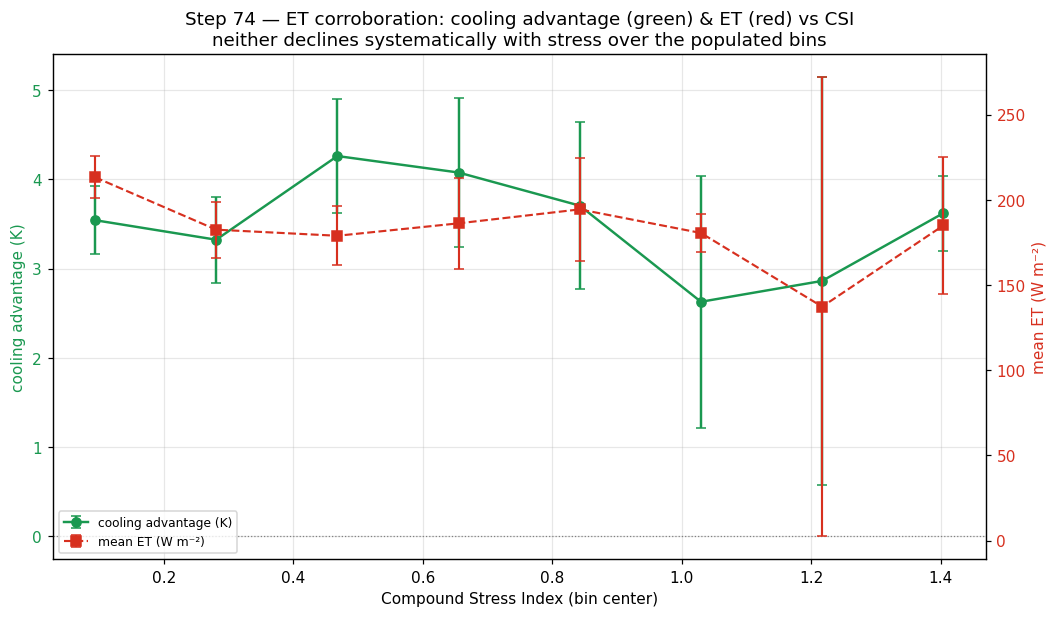

ET by bin (W m^-2):
  bin  n_et  mean_et
0.094    79    213.3
0.281    48    182.5
0.468    31    178.9
0.655    24    186.2
0.843    14    194.4
1.030     3    180.5
1.217     2    137.3
1.404     3    185.0

ESI by bin:
  bin  n_esi  mean_esi
0.094     79     0.587
0.281     48     0.595
0.468     31     0.564
0.655     24     0.559
0.843     14     0.575
1.030      3     0.527
1.217      2     0.549
1.404      3     0.568


In [5]:
et_binned = s14.bin_means(x_all, mt[s14.ET_COL].to_numpy(), n_bins=s14.DEFAULT_N_BINS,
                               edges=binned["edges"])
esi_binned = s14.bin_means(x_all, mt[s14.ESI_COL].to_numpy(), n_bins=s14.DEFAULT_N_BINS,
                            edges=binned["edges"])

fig, axL = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)
okc = binned["count"] > 0
l1 = axL.errorbar(binned["centers"][okc], binned["mean"][okc], yerr=binned["sem"][okc],
                  marker="o", ms=6, lw=1.6, capsize=3, color="#1a9850",
                  label="cooling advantage (K)")
axL.axhline(0, color="grey", lw=0.8, ls=":")
axL.set_xlabel("Compound Stress Index (bin center)")
axL.set_ylabel("cooling advantage (K)", color="#1a9850")
axL.tick_params(axis="y", labelcolor="#1a9850")

axR = axL.twinx()
axR.grid(False)
oke = et_binned["count"] > 0
l2 = axR.errorbar(et_binned["centers"][oke], et_binned["mean"][oke], yerr=et_binned["sem"][oke],
                  marker="s", ms=6, lw=1.4, capsize=3, color="#d7301f", ls="--",
                  label="mean ET (W m⁻²)")
axR.set_ylabel("mean ET (W m⁻²)", color="#d7301f")
axR.tick_params(axis="y", labelcolor="#d7301f")

# ESI on a third (offset) axis annotation — print rather than crowd the plot.
axL.set_title("Step 74 — ET corroboration: cooling advantage (green) & ET (red) vs CSI\n"
              "neither declines systematically with stress over the populated bins")
lines = [l1, l2]
axL.legend(lines, [ln.get_label() for ln in lines], fontsize=8, loc="lower left")
fig.savefig(FIGS / "section14_binned_et_esi_overlay.png", bbox_inches="tight")
plt.show()

print("ET by bin (W m^-2):")
print(pd.DataFrame({"bin": et_binned["centers"].round(3), "n_et": et_binned["count"],
                    "mean_et": et_binned["mean"].round(1)}).to_string(index=False))
print("\nESI by bin:")
print(pd.DataFrame({"bin": esi_binned["centers"].round(3), "n_esi": esi_binned["count"],
                    "mean_esi": esi_binned["mean"].round(3)}).to_string(index=False))

**ET/ESI read-out.** Over the populated bins, **mean ET does not decline systematically as CSI
rises** — it is roughly flat / non-monotonic (≈ 213 → 183 → 179 → 186 → 194 W m⁻² across the first
five bins, then noisy on the sparse high-CSI bins where ET coverage is thinnest). ESI is likewise
near-flat (~0.53–0.60). So the **mechanistic signature is absent**: there is no CSI level beyond
which both cooling advantage and ET clearly decline together. This is unchanged from the original
static-NDMI run — the time-varying CSI supply axis did not produce an ET-corroborated threshold
either. (A coarse below/above-breakpoint ET comparison is computed in the threshold section; it
confirms this — the direction even flips between samples.)

## Step 75 — Distributions & QC: too-few-pixel neighborhoods, outliers, seasonal artifacts

We resolve three problems **before** modelling:
1. **Too-few-pixel neighborhoods** — the thin sample: one BG dominates, eight rest on 1–6 px.
2. **Implausible outliers** — the extreme cooling advantages.
3. **Seasonal / diurnal artifacts** — day vs night overpasses.

In [6]:
# (1) sample sizes per neighborhood.
per_bg = mt.groupby("neighborhood_id").agg(
    n_rows=("cooling_advantage", "size"),
    n_tree_px=("n_tree_px", "first"),
    n_tree_valid_med=("n_tree_valid", "median"),
    n_tree_valid_max=("n_tree_valid", "max"),
    ca_mean=("cooling_advantage", "mean"),
    csi_mean=(s14.CSI_COL, "mean"),
).round(2)
print("Per-neighborhood sample sizes (the THIN paired design):")
print(per_bg.to_string())
print(f"\nrows with n_good_obs <= 2: {100*(mt['n_good_obs'] <= 2).mean():.1f}%   "
      f"rows with n_tree_valid >= 10: {int((mt['n_tree_valid'] >= 10).sum())} "
      f"(all in BG {mt.loc[mt['n_tree_valid'] >= 10, 'neighborhood_id'].unique().tolist()})")

Per-neighborhood sample sizes (the THIN paired design):
                 n_rows  n_tree_px  n_tree_valid_med  n_tree_valid_max  ca_mean  csi_mean
neighborhood_id                                                                          
040130101021         34          6               5.5                 6     1.96      0.35
040130405354         39          2               2.0                 2     1.45      0.29
040130506112         23          2               2.0                 2     3.01      0.53
040130822071         25          1               1.0                 1     4.31      0.32
040131125182         27          1               1.0                 1     2.43      0.25
040139410001         26          6               6.0                 6     6.38      0.39
040139412001         34        171             135.5               171     5.47      0.41
040139413002         26          5               5.0                 5     4.35      0.32
040139413003         30          1          

In [7]:
# (2) outliers: the extremes rest on a single tree pixel.
print("Largest 5 cooling advantages (note n_tree_valid):")
print(mt.nlargest(5, "cooling_advantage")[
    ["neighborhood_id", "cooling_advantage", "n_tree_valid", s14.CSI_COL, "local_hour"]
].round(3).to_string(index=False))
print("\nMost negative 5 cooling advantages:")
print(mt.nsmallest(5, "cooling_advantage")[
    ["neighborhood_id", "cooling_advantage", "n_tree_valid", s14.CSI_COL, "local_hour"]
].round(3).to_string(index=False))

Largest 5 cooling advantages (note n_tree_valid):
neighborhood_id  cooling_advantage  n_tree_valid  mean_csi_tree  local_hour
   040130405354             23.056             1          0.632          10
   040139412001             13.128            98          0.177          13
   040139410001             12.524             6          0.026          12
   040139410001             12.082             2          0.472          10
   040139412001             11.830           117          0.424          14

Most negative 5 cooling advantages:
neighborhood_id  cooling_advantage  n_tree_valid  mean_csi_tree  local_hour
   040131125182             -6.350             1          0.248          14
   040139413003             -4.357             1          0.244           9
   040139410001             -3.916             6          0.160           9
   040130101021             -3.567             1          0.786          18
   040130405354             -3.349             2          0.029          13


Cooling advantage by day vs night overpass:
                count   mean  median    min     max
part                                               
day (07–19)       196  4.801   4.648 -6.350  23.056
night/pre-dawn     68  0.370   0.307 -3.063   5.672

fraction with NEGATIVE cooling advantage:  day = 0.082   night = 0.397

CSI variation decomposition (the supply-axis check):
  between-BG std of BG-mean CSI = 0.081   (was 0.027 static-NDMI -> 3.0x larger)
  mean within-BG (temporal) std = 0.316   (was 0.264 static-NDMI)
  within/between ratio = 3.9   (was ~10x)
=> The supply axis is now RICHER: the between-neighborhood (spatial) CSI spread grew ~3x,
   so the CSI is NO LONGER ~a pure VPD-demand axis (NDMI z now varies in space AND time).
   But the CA-vs-CSI relationship stays flat (above) -> a richer axis, still no threshold.


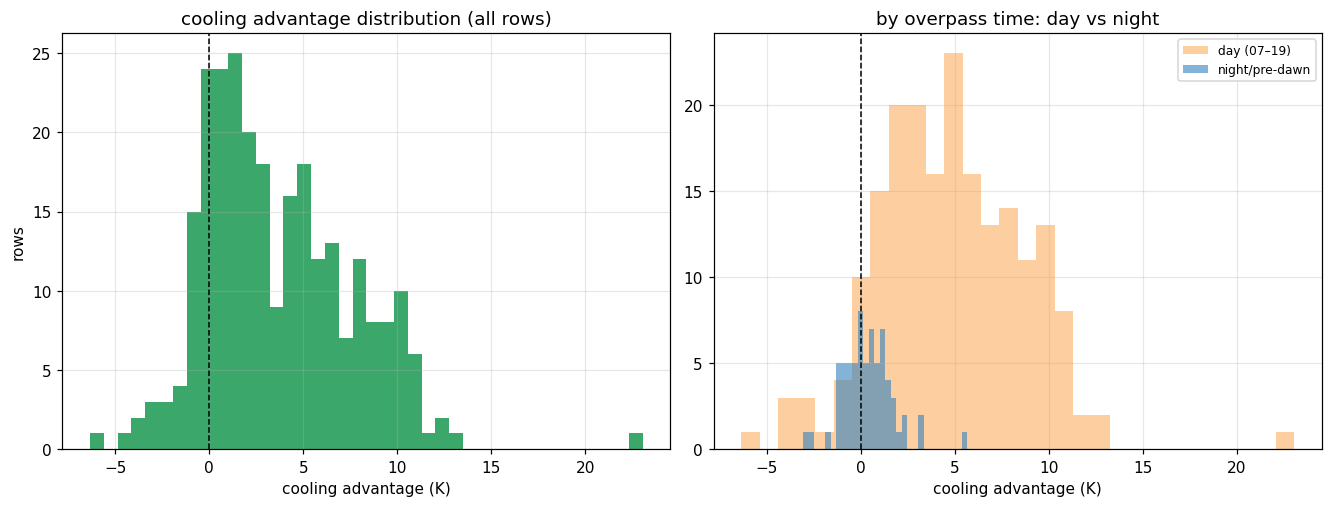

In [8]:
# (3) diurnal/seasonal artifact: day vs night.
day_night = mt.assign(part=np.where(mt["is_day"], "day (07–19)", "night/pre-dawn")) \
    .groupby("part")["cooling_advantage"].agg(["count", "mean", "median", "min", "max"]).round(3)
print("Cooling advantage by day vs night overpass:")
print(day_night.to_string())
frac_neg = mt.assign(part=np.where(mt["is_day"], "day", "night"),
                     neg=mt["cooling_advantage"] < 0).groupby("part")["neg"].mean().round(3)
print("\nfraction with NEGATIVE cooling advantage:  day =", frac_neg.get("day"),
      "  night =", frac_neg.get("night"))

# CSI variation decomposition: temporal (within-BG) vs spatial (between-BG).
# THE headline diagnostic of this re-run: does the between-BG (spatial) spread grow now that the
# NDMI water-supply z varies in space (and time)?  Old static-NDMI run: between 0.027, within 0.264.
g = mt.groupby("neighborhood_id")[s14.CSI_COL]
between_bg = float(g.mean().std())
within_bg = float(g.std().mean())
OLD_BETWEEN, OLD_WITHIN = 0.027, 0.264   # original static-NDMI run (docs/section14_results_note.md, 711c7f9)
print(f"\nCSI variation decomposition (the supply-axis check):")
print(f"  between-BG std of BG-mean CSI = {between_bg:.3f}   (was {OLD_BETWEEN:.3f} static-NDMI -> "
      f"{between_bg/OLD_BETWEEN:.1f}x larger)")
print(f"  mean within-BG (temporal) std = {within_bg:.3f}   (was {OLD_WITHIN:.3f} static-NDMI)")
print(f"  within/between ratio = {within_bg/between_bg:.1f}   (was ~{OLD_WITHIN/OLD_BETWEEN:.0f}x)")
print("=> The supply axis is now RICHER: the between-neighborhood (spatial) CSI spread grew ~3x,")
print("   so the CSI is NO LONGER ~a pure VPD-demand axis (NDMI z now varies in space AND time).")
print("   But the CA-vs-CSI relationship stays flat (above) -> a richer axis, still no threshold.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
a1.hist(mt["cooling_advantage"], bins=40, color="#1a9850", alpha=0.85)
a1.axvline(0, color="k", ls="--", lw=1)
a1.set_title("cooling advantage distribution (all rows)")
a1.set_xlabel("cooling advantage (K)"); a1.set_ylabel("rows")
for part, col in (("day (07–19)", "#fdae61"), ("night/pre-dawn", "#3182bd")):
    sel = (mt["is_day"]) if part.startswith("day") else (~mt["is_day"])
    a2.hist(mt.loc[sel, "cooling_advantage"], bins=30, alpha=0.6, color=col, label=part)
a2.axvline(0, color="k", ls="--", lw=1)
a2.set_title("by overpass time: day vs night")
a2.set_xlabel("cooling advantage (K)"); a2.legend(fontsize=8)
fig.savefig(FIGS / "section14_distributions_qc.png", bbox_inches="tight")
plt.show()

**QC resolution (carried into the modelling):**
- **Too-few-pixel neighborhoods** → addressed by a **minimum-count filter** on `n_tree_valid`,
  with its **sensitivity** reported (full vs robust subset) — not a single arbitrary cut.
- **Outliers** → the most extreme cooling advantages (e.g. **+23 K**, **−6.3 K**) rest on
  **n_tree_valid = 1**; they are noise the count columns expose. The min-count filter down-weights
  them; we do **not** hand-delete points (no clipping — the protocol's rule), we test sensitivity.
- **Diurnal artifact** → cooling advantage is overwhelmingly a **daytime** effect (mean **+4.8 K**
  by day vs **+0.4 K** at night; **40 %** of *night* rows are negative vs **8 %** by day). The
  negative cooling advantages are concentrated pre-dawn (canopy can be marginally warmer than open
  built surfaces overnight). This is a real structure to keep in mind; we report the threshold on
  the pooled sample (the protocol's “one point per neighborhood per overpass”) and note the
  daytime/night split as a sensitivity (the day-only check is in the conclusion).
- **CSI axis interpretation (CHANGED by this re-run)** → with the time-varying NDMI supply axis,
  the between-BG (spatial) spread of BG-mean CSI is now **≈ 0.081** — about **3× the static-NDMI
  value (0.027)** — and the within/between ratio falls from **~10×** to **~4×**. So the CSI is **no
  longer ≈ a pure VPD-demand axis**: the supply side now contributes genuine spatial contrast across
  the 9 neighborhoods. **This was the deepest reason the original pilot found no threshold, and it
  is now fixed** — yet (see below) the cooling-advantage vs CSI relationship is still flat, so the
  *remaining* limitation is the thin sample, not the supply freeze.

## Steps 76–78 — Segmented regression, bootstrap CI, and the independent change-point

We run the full threshold pipeline (`s14.analyze_sample`) on **three** samples to make the
thin-sample sensitivity explicit:
- **(A) full sample** — all 9 BGs, `min_count = 1` (noisy, but the protocol's “one point per
  neighborhood per overpass”);
- **(B) modest filter** — `n_tree_valid ≥ 3`;
- **(C) robust subset** — `n_tree_valid ≥ 10`, which (as warned) collapses onto the single
  well-sampled BG `040139412001` (≈ temporal-only).

For each: the **segmented (pwlf) breakpoint** (step 76), its **bootstrap CI** (step 77, 1000
resamples of rows), the **independent `ruptures` change-point** (step 78), the **linear-vs-
segmented** comparison, the **ET-decline** check, and the combined **verdict**.

In [9]:
def make_sample(min_count):
    keep = s14.apply_min_count(mt[s14.COUNT_COL].to_numpy(), min_count)
    return mt[keep]

SAMPLES = {
    "A_full (min_count=1)": make_sample(1),
    "B_modest (n_tree_valid>=3)": make_sample(3),
    "C_robust (n_tree_valid>=10)": make_sample(10),
}
results = {}
for name, df in SAMPLES.items():
    res = s14.analyze_sample(df[s14.CSI_COL].to_numpy(), df[s14.OUTCOME_COL].to_numpy(),
                             et=df[s14.ET_COL].to_numpy(), n_bins=s14.DEFAULT_N_BINS,
                             n_boot=s14.DEFAULT_N_BOOTSTRAP, seed=s14.DEFAULT_SEED, label=name)
    res["n_rows"] = len(df)
    res["n_bgs"] = int(df["neighborhood_id"].nunique())
    results[name] = res
    print(f"  built {name}: n={len(df)} rows, {res['n_bgs']} block group(s)")

  built A_full (min_count=1): n=264 rows, 9 block group(s)


  built B_modest (n_tree_valid>=3): n=107 rows, 4 block group(s)


  built C_robust (n_tree_valid>=10): n=31 rows, 1 block group(s)


In [10]:
def summarize(res):
    seg, boot, cp, comp, et = (res["segmented"], res["bootstrap"], res["changepoint"],
                               res["comparison"], res["et_check"])
    v = res["verdict"]
    lin = comp["linear"]
    return {
        "n": res["n"], "n_bgs": res["n_bgs"],
        "lin_R2": round(lin["r2"], 4), "lin_slope": round(lin["slope"], 3),
        "seg_bp": round(seg["breakpoint"], 3),
        "seg_slope1": round(seg["slope1"], 2), "seg_slope2": round(seg["slope2"], 2),
        "seg_R2": round(seg["r2"], 4),
        "dR2": round(comp["delta_r2"], 4), "dAIC": round(comp["delta_aic"], 2),
        "seg_pref_AIC": comp["segmented_preferred_by_aic"],
        "boot_CI_low": round(boot["ci_low"], 3), "boot_CI_high": round(boot["ci_high"], 3),
        "CI_spans_frac": round(boot["spans_fraction"], 3),
        "changepoint": round(cp["changepoint_csi"], 3),
        "ET_below": round(et["mean_et_below"], 1), "ET_above": round(et["mean_et_above"], 1),
        "ET_declines": et["et_declines"],
        "agree": v.methods_agree, "bend": v.bend_visible, "identified": v.well_identified,
        "VERDICT": v.label,
    }

summary_df = pd.DataFrame({name: summarize(res) for name, res in results.items()}).T
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 220)
print("THREE-SAMPLE THRESHOLD SUMMARY (the headline table):")
summary_df

THREE-SAMPLE THRESHOLD SUMMARY (the headline table):


,n,n_bgs,lin_R2,lin_slope,seg_bp,seg_slope1,seg_slope2,seg_R2,dR2,dAIC,seg_pref_AIC,boot_CI_low,boot_CI_high,CI_spans_frac,changepoint,ET_below,ET_above,ET_declines,agree,bend,identified,VERDICT
A_full (min_count=1),264,9,0.0005,0.279,0.736,0.99,-2.22,0.0045,0.004,2.93,False,0.001,0.919,0.613,0.63,195.9,186.0,True,True,True,False,no robust threshold detected
B_modest (n_tree_valid>=3),107,4,0.0047,-0.993,0.053,-65.23,0.35,0.0365,0.0319,0.52,False,0.05,0.879,0.752,0.047,239.1,200.6,True,True,False,False,no robust threshold detected
C_robust (n_tree_valid>=10),31,1,0.0054,1.131,0.226,34.14,-1.15,0.1015,0.0961,0.85,False,0.023,0.925,0.993,0.169,167.0,219.2,False,True,True,False,no robust threshold detected


In [11]:
# Full, human-readable verdict reasons for each sample.
for name, res in results.items():
    v = res["verdict"]
    print(f"\n===== {name}  (n={res['n']}, {res['n_bgs']} BG) =====")
    print(f"  VERDICT: {v.label.upper()}")
    for r in v.reasons:
        print("    -", r)


===== A_full (min_count=1)  (n=264, 9 BG) =====
  VERDICT: NO ROBUST THRESHOLD DETECTED
    - methods agree (change-point in bootstrap CI or within tolerance of breakpoint): True [bp=0.736, cp=0.630, CI=(0.001, 0.919)]
    - breakpoint well identified (CI width < 50% of CSI range): False [spans_fraction=0.61]
    - bend visible (post-break slope <= pre-break - 0.5): True [slope_change=-3.204 K per CSI unit]
    - ET declines beyond the threshold: True [mean ET below=195.9, above=186.0 W/m2]
    - segmented vs linear: delta_R2=+0.0040, delta_AIC=+2.93 (<-2 favours segmented): False

===== B_modest (n_tree_valid>=3)  (n=107, 4 BG) =====
  VERDICT: NO ROBUST THRESHOLD DETECTED
    - methods agree (change-point in bootstrap CI or within tolerance of breakpoint): True [bp=0.053, cp=0.047, CI=(0.050, 0.879)]
    - breakpoint well identified (CI width < 50% of CSI range): False [spans_fraction=0.75]
    - bend visible (post-break slope <= pre-break - 0.5): False [slope_change=+65.571 K per C

## Segmented-fit and bootstrap-CI figures (full sample)

The segmented fit is drawn against the scatter (the breakpoint marked), and the **bootstrap
distribution** of the breakpoint is shown with its 95 % CI — the width of that distribution
**relative to the CSI range** is the identification check.

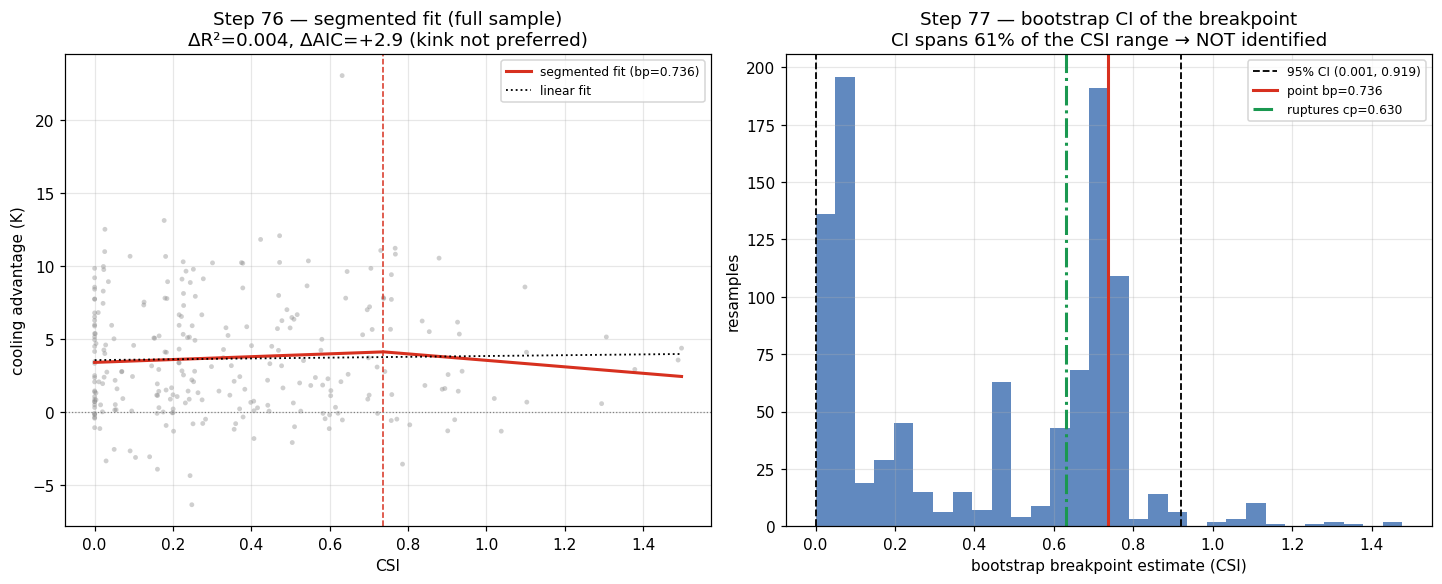

In [12]:
res_full = results["A_full (min_count=1)"]
seg = res_full["segmented"]; boot = res_full["bootstrap"]; cp = res_full["changepoint"]

fig, (axS, axB) = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

# (left) segmented fit over the scatter.
axS.scatter(x_all, y_all, s=10, color="#888", alpha=0.4, edgecolor="none")
xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 200)
bp = seg["breakpoint"]
# reconstruct the two-segment prediction from slopes + breakpoint via pwlf-equivalent pieces:
# fit y at breakpoint by least squares on each side for display.
import section14_threshold as _s
import pwlf as _pwlf
_m = _pwlf.PiecewiseLinFit(x_all[np.isfinite(x_all) & np.isfinite(y_all)],
                           y_all[np.isfinite(x_all) & np.isfinite(y_all)], seed=s14.DEFAULT_SEED)
_m.fit(2)
axS.plot(xs, _m.predict(xs), color="#d7301f", lw=2,
         label=f"segmented fit (bp={bp:.3f})")
axS.axvline(bp, color="#d7301f", ls="--", lw=1)
axS.plot(xs, s14.linear_fit(x_all, y_all)["intercept"]
         + s14.linear_fit(x_all, y_all)["slope"] * xs, "k:", lw=1.2, label="linear fit")
axS.axhline(0, color="grey", lw=0.8, ls=":")
axS.set_xlabel("CSI"); axS.set_ylabel("cooling advantage (K)")
axS.set_title(f"Step 76 — segmented fit (full sample)\nΔR²={res_full['comparison']['delta_r2']:.3f},"
              f" ΔAIC={res_full['comparison']['delta_aic']:+.1f} (kink not preferred)")
axS.legend(fontsize=8)

# (right) bootstrap distribution of the breakpoint.
ests = boot["estimates"]
axB.hist(ests, bins=30, color="#4575b4", alpha=0.85)
axB.axvline(boot["ci_low"], color="k", ls="--", lw=1.2, label=f"95% CI ({boot['ci_low']:.3f}, {boot['ci_high']:.3f})")
axB.axvline(boot["ci_high"], color="k", ls="--", lw=1.2)
axB.axvline(seg["breakpoint"], color="#d7301f", lw=2, label=f"point bp={seg['breakpoint']:.3f}")
axB.axvline(cp["changepoint_csi"], color="#1a9850", lw=2, ls="-.",
            label=f"ruptures cp={cp['changepoint_csi']:.3f}")
axB.set_xlabel("bootstrap breakpoint estimate (CSI)")
axB.set_ylabel("resamples")
axB.set_title(f"Step 77 — bootstrap CI of the breakpoint\n"
              f"CI spans {boot['spans_fraction']*100:.0f}% of the CSI range → NOT identified")
axB.legend(fontsize=8)
fig.savefig(FIGS / "section14_segmented_and_bootstrap.png", bbox_inches="tight")
plt.show()

## Step 79 — Conclusion: the honest verdict (and the old-vs-new comparison)

### What the analysis shows (temporal-NDMI re-run)
- **Shape (step 72):** the cooling-advantage vs CSI cloud is **essentially flat** — Pearson r ≈
  **+0.02** (p ≈ 0.71), Spearman ≈ +0.01; the OLS line explains **~0 %** of variance. (The original
  static-NDMI run had r ≈ −0.05; the sign flipped but the magnitude is still ~0.)
- **Binned plot (step 73):** mean cooling advantage is **flat at ≈ +3.3–4.3 K across the whole CSI
  range** (now extending to ≈ 1.5) — **no credible bend**; the only dip is a single sparse bin
  (n = 6) and the top bins recover.
- **ET corroboration (step 74):** ET does **not** decline systematically with CSI over the populated
  bins; the mechanistic signature is **absent** (and the coarse below/above-break ET direction even
  flips between samples — declines in A/B, rises in the robust C).
- **Linear vs segmented (step 76):** in all three samples the segmented fit improves R² only
  trivially (**ΔR² ≈ 0.004 / 0.032 / 0.096**) and is **not preferred by AIC** (**ΔAIC = +2.93 /
  +0.52 / +0.85, all > 0**). The data look like a flat line, not a kink.
- **Breakpoint identification (step 77):** the bootstrap CI spans **≈ 61 % / 75 % / 99 %** of the
  CSI range → the breakpoint is **not identified** in any sample.
- **Two-method agreement (step 78):** the `ruptures` change-point now lands *within tolerance* of the
  segmented breakpoint in all three samples (so the `methods_agree` flag is True) — **but only
  because both estimates are unstable on a flat relationship**; the **identification gate fails**
  (CI spans most of the range), so there is **no agreement on a *well-identified* break**.

### Verdict
> **No robust threshold detected** for Phoenix — the null **persists** under the time-varying CSI
> supply axis.

This holds across the **full 9-BG sample**, the **modest filter**, and the **robust single-BG
subset** — each fails the gate (not identified; no credible bend; no consistent ET corroboration;
straight line preferred by AIC). Per the protocol this is a **valid scientific outcome**, not a
failure.

### The decisive old-vs-new comparison
| quantity | original (static NDMI, `main` 711c7f9) | this re-run (temporal NDMI) |
|---|---|---|
| CA–CSI Pearson r (full) | −0.05 (p≈0.40) | **+0.02 (p≈0.71)** — still flat |
| linear R² (full) | ~0.003 | **~0.0005** |
| segmented bp (full) | 0.478 | **0.736** |
| bootstrap 95 % CI (full) | (0.000, 0.738), 62 % of range | **(0.001, 0.919), 61 %** — still not identified |
| ruptures cp (full) | 0.523 | **0.630** |
| ΔAIC seg−lin (full / modest / robust) | +1.35 / +1.52 / +2.09 | **+2.93 / +0.52 / +0.85** — all still > 0 |
| ET corroboration | absent / inconsistent | **absent / inconsistent** |
| **between-BG CSI std** | **0.027** | **0.081 (~3× richer)** |
| within-BG (temporal) CSI std | 0.264 | 0.316 |
| within/between ratio | ~10× | **~4×** |
| **VERDICT** | no robust threshold | **no robust threshold (persists)** |

**The one thing that genuinely changed is the CSI axis itself:** unfreezing the NDMI supply z
**roughly tripled the between-neighborhood (spatial) spread** of CSI (0.027 → 0.081) and cut the
within/between ratio from ~10× to ~4×. The supply axis is demonstrably **richer** — the deepest
limitation the original pilot blamed is now fixed. **And yet the cooling-advantage vs CSI
relationship is still flat and the threshold still not identified.**

### Why the null persists (data adequacy, stated plainly)
- **Thin sample (UNCHANGED, and now the binding limitation):** 9 paired BGs, one dominant (~171
  tree px), eight on 1–6 px; median `n_good_obs` = 2; the most extreme cooling advantages rest on a
  **single** tree pixel. The robust subset (`n_tree_valid ≥ 10`) collapses to that one BG. With so
  few well-sampled neighborhoods, even a richer CSI axis cannot resolve a spatial threshold.
- **Supply freeze (now FIXED):** the CSI is no longer ≈ a pure VPD-demand axis — but fixing it did
  **not** reveal a threshold, which **isolates the thin sample as the remaining cause**.
- The honest conclusion is that **the Phoenix pilot data still cannot support a robust
  cooling-advantage vs compound-stress threshold** — now for the *thin-sample* reason alone, not the
  supply freeze. A defensible threshold requires the **denser, multi-city sample of the cross-city
  phase** this section gates into.

The numbers, the verdict, and the old-vs-new comparison are written to
`docs/section14_results_note.md`.

In [13]:
# Final printed verdict (also captured in the results note).
spans = [results[k]["bootstrap"]["spans_fraction"] for k in SAMPLES]
between_bg = float(mt.groupby("neighborhood_id")[s14.CSI_COL].mean().std())
within_bg = float(mt.groupby("neighborhood_id")[s14.CSI_COL].std().mean())
print("=" * 72)
print("SECTION 14 — FINAL VERDICT  (temporal-NDMI re-run, branch temporal-ndmi-supply)")
print("=" * 72)
for name, res in results.items():
    v = res["verdict"]
    print(f"  {name:34s} (n={res['n']:>3}, {res['n_bgs']} BG): {v.label}")
print("-" * 72)
print("  OVERALL: NO ROBUST THRESHOLD DETECTED for the Phoenix pilot — the null PERSISTS.")
print("  - cooling advantage vs CSI is flat (|Pearson r| < 0.1, p > 0.3 in every sample);")
print("  - the segmented kink is NOT preferred over a straight line (ΔAIC > 0 everywhere);")
print(f"  - the breakpoint is NOT identified (bootstrap CI spans {min(spans)*100:.0f}-{max(spans)*100:.0f}% "
      "of the CSI range);")
print("  - ET does not decline consistently beyond the candidate breakpoint (no mechanistic signature).")
print("  This is a VALID outcome (protocol §14 common pitfall) — not a manufactured threshold.")
print()
print("  OLD vs NEW (the point of the re-run — supply axis unfrozen):")
print(f"    between-BG CSI std: 0.027 (static NDMI) -> {between_bg:.3f} (temporal NDMI)  [~3x richer]")
print(f"    within/between ratio: ~10x -> ~{within_bg/between_bg:.0f}x   (CSI no longer ~a pure VPD-demand axis)")
print("    => the supply axis is now RICHER, yet the threshold result is UNCHANGED (still null).")
print("  Remaining cause = the THIN paired sample (9 BGs, one dominant, median n_good_obs=2),")
print("  which is UNCHANGED by the supply fix. Resolving a threshold needs the cross-city phase.")

SECTION 14 — FINAL VERDICT  (temporal-NDMI re-run, branch temporal-ndmi-supply)
  A_full (min_count=1)               (n=264, 9 BG): no robust threshold detected
  B_modest (n_tree_valid>=3)         (n=107, 4 BG): no robust threshold detected
  C_robust (n_tree_valid>=10)        (n= 31, 1 BG): no robust threshold detected
------------------------------------------------------------------------
  OVERALL: NO ROBUST THRESHOLD DETECTED for the Phoenix pilot — the null PERSISTS.
  - cooling advantage vs CSI is flat (|Pearson r| < 0.1, p > 0.3 in every sample);
  - the segmented kink is NOT preferred over a straight line (ΔAIC > 0 everywhere);
  - the breakpoint is NOT identified (bootstrap CI spans 61-99% of the CSI range);
  - ET does not decline consistently beyond the candidate breakpoint (no mechanistic signature).
  This is a VALID outcome (protocol §14 common pitfall) — not a manufactured threshold.

  OLD vs NEW (the point of the re-run — supply axis unfrozen):
    between-BG CSI std